# Import the libraries

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# Seinfeld dataset

ghcp-instructions

* use data/seinfeld.csv

* simple scatter plot below

Season 10 projected viewers (millions): 39.98


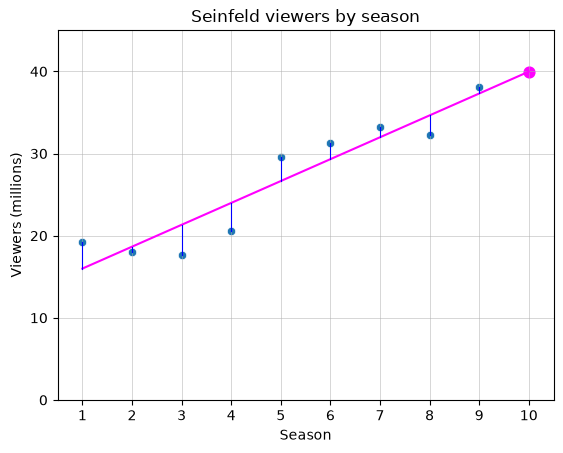

In [40]:
df_seinfeld = pd.read_csv('data/seinfeld.csv')
X_seinfeld = df_seinfeld[['season']]
y_seinfeld = df_seinfeld['viewers-in-millions']
seinfeld_model = LinearRegression()
seinfeld_model.fit(X_seinfeld, y_seinfeld)
y_seinfeld_pred = seinfeld_model.predict(X_seinfeld)
projection_df = pd.DataFrame({'season': range(int(df_seinfeld['season'].min()), 11)})
projection_pred = seinfeld_model.predict(projection_df[['season']])
season_10_pred = seinfeld_model.predict(pd.DataFrame({'season': [10]}))[0]
sns.scatterplot(data=df_seinfeld, x='season', y='viewers-in-millions')
plt.plot(projection_df['season'], projection_pred, color='magenta')
plt.scatter([10], [season_10_pred], color='magenta', s=60)
for season, actual, predicted in zip(df_seinfeld['season'], y_seinfeld, y_seinfeld_pred):
    plt.plot([season, season], [actual, predicted], color='blue', linewidth=0.8)
plt.title('Seinfeld viewers by season')
plt.xlabel('Season')
plt.ylabel('Viewers (millions)')
plt.xlim(df_seinfeld['season'].min() - 0.5, 10.5)
plt.ylim(0, 45)
plt.xticks(range(int(df_seinfeld['season'].min()), 11, 1))
plt.yticks(range(0, 46, 10))
plt.grid(True, axis='both', which='major', linewidth=0.6, alpha=0.6)
print(f'Season 10 projected viewers (millions): {season_10_pred:.2f}')
plt.show()

# Import dataset

In [19]:
df = pd.read_csv('data/tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Exploratory data analysis

In [20]:
df_corr = df.corr(numeric_only=True)

<Axes: >

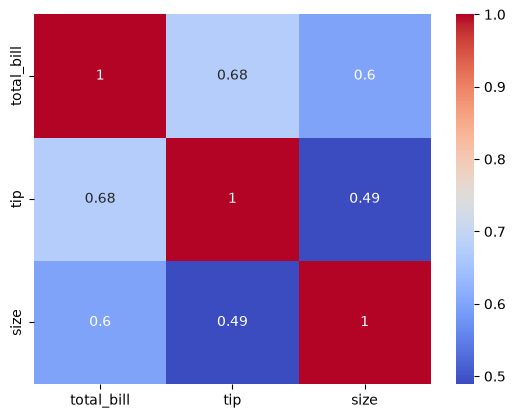

In [21]:
sns.heatmap(df_corr, annot=True, cmap='coolwarm')

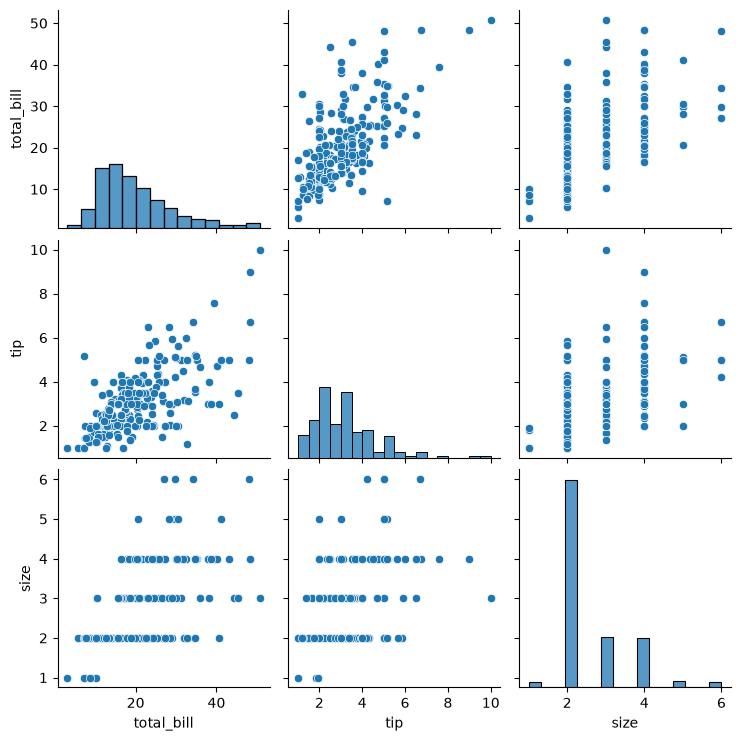

In [22]:
sns.pairplot(df)

In [23]:
# Convert non-numeric data using one-hot encoding
df = pd.get_dummies(df, columns=['time', 'day', 'smoker', 'sex'])
df.head()

,total_bill,tip,size,time_Dinner,time_Lunch,day_Fri,day_Sat,day_Sun,day_Thur,smoker_No,smoker_Yes,sex_Female,sex_Male
0,16.99,1.01,2,True,False,False,False,True,False,True,False,True,False
1,10.34,1.66,3,True,False,False,False,True,False,True,False,False,True
2,21.01,3.50,3,True,False,False,False,True,False,True,False,False,True
3,23.68,3.31,2,True,False,False,False,True,False,True,False,False,True
4,24.59,3.61,4,True,False,False,False,True,False,True,False,True,False


In [24]:
df_corr = df.corr()
df_corr

,total_bill,tip,size,time_Dinner,time_Lunch,day_Fri,day_Sat,day_Sun,day_Thur,smoker_No,smoker_Yes,sex_Female,sex_Male
total_bill,1.000000,0.675734,0.598315,0.183118,-0.183118,-0.086168,0.054919,0.122953,-0.138174,-0.085721,0.085721,-0.144877,0.144877
tip,0.675734,1.000000,0.489299,0.121629,-0.121629,-0.055463,-0.002790,0.125114,-0.095879,-0.005929,0.005929,-0.088862,0.088862
size,0.598315,0.489299,1.000000,0.103411,-0.103411,-0.142184,-0.041121,0.193054,-0.072598,0.133178,-0.133178,-0.086195,0.086195
time_Dinner,0.183118,0.121629,0.103411,1.000000,-1.000000,-0.058159,0.462709,0.418071,-0.917996,-0.054921,0.054921,-0.205231,0.205231
time_Lunch,-0.183118,-0.121629,-0.103411,-1.000000,1.000000,0.058159,-0.462709,-0.418071,0.917996,0.054921,-0.054921,0.205231,-0.205231
day_Fri,-0.086168,-0.055463,-0.142184,-0.058159,0.058159,1.000000,-0.216319,-0.195451,-0.169608,-0.244316,0.244316,0.071060,-0.071060
day_Sat,0.054919,-0.002790,-0.041121,0.462709,-0.462709,-0.216319,1.000000,-0.500682,-0.434480,-0.155744,0.155744,-0.053957,0.053957
day_Sun,0.122953,0.125114,0.193054,0.418071,-0.418071,-0.195451,-0.500682,1.000000,-0.392566,0.181624,-0.181624,-0.168106,0.168106
day_Thur,-0.138174,-0.095879,-0.072598,-0.917996,0.917996,-0.169608,-0.434480,-0.392566,1.000000,0.128534,-0.128534,0.194445,-0.194445
smoker_No,-0.085721,-0.005929,0.133178,-0.054921,0.054921,-0.244316,-0.155744,0.181624,0.128534,1.000000,-1.000000,0.002816,-0.002816


# Split the dataset

In [25]:
X = df.drop(['tip', 'smoker_Yes', 'smoker_No'], axis=1)
y = df['tip']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Create and train the model

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.07, 0.35,-0.05,...,-0.14,-0.03, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['total_bill','size','time_Dinner',...,'day_Thur','sex_Female','sex_Male']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6803
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [28]:
model.intercept_

np.float64(0.6803169796550037)

In [29]:
model.coef_

array([ 0.0749946 ,  0.34859861, -0.04828556,  0.04828556,  0.11008726,
       -0.07223806,  0.10341838, -0.14126759, -0.0307065 ,  0.0307065 ])

In [30]:
# Validate the model
mae_train = mean_absolute_error(y_train, model.predict(X_train))
print("Training set Mean Absolute Error: %.2f" % mae_train)

mae_test = mean_absolute_error(y_test, model.predict(X_test))
print("Test set Mean Absolute Error: %.2f" % mae_test)

Training set Mean Absolute Error: 0.75
Test set Mean Absolute Error: 0.75
